# Waypoint Visualizer
Plots drone and spot waypoints on an interactive satellite basemap (folium).

**File format** (one waypoint per line): `lat,lon,yaw_rad`  
**Yaw convention**: 0 = south, increases CCW, arrow points toward the target.

In [1]:
import math
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
DRONE_FILE     = Path("/tmp/drone_debug/drone_waypoints.txt")
SPOT_FILE      = Path("/tmp/drone_debug/spot_waypoints.txt")
PROJ_FILE      = Path("/tmp/drone_debug/projected_waypoints.txt")
PNG_OUT        = Path("/tmp/drone_debug/map.png")

DRONE_COLOR    = "royalblue"
SPOT_COLOR     = "limegreen"
PROJ_COLOR     = "orange"
ARROW_M        = 4.0   # yaw arrow length in metres
ZOOM           = 18    # satellite tile zoom (17=~1.2 m/px, 18=~0.6 m/px at 30°)
PAD_TILES      = 1     # extra tiles of padding around the waypoints
TILE_SIZE      = 256   # pixels per tile (Esri standard)

In [3]:
def load_waypoints(path):
    waypoints = []
    for line in Path(path).read_text().splitlines():
        line = line.strip()
        if line:
            lat, lon, yaw = map(float, line.split(","))
            waypoints.append((lat, lon, yaw))
    return waypoints

def yaw_endpoint(lat, lon, yaw_rad, metres):
    d_north = metres * -math.cos(yaw_rad)
    d_east  = metres *  math.sin(yaw_rad)
    lat2 = lat + math.degrees(d_north / 6_378_137.0)
    lon2 = lon + math.degrees(d_east  / (6_378_137.0 * math.cos(math.radians(lat))))
    return lat2, lon2

# ── Tile helpers ──────────────────────────────────────────────────────────────

def _ll_to_tile(lat, lon, zoom):
    n = 2 ** zoom
    tx = int((lon + 180) / 360 * n)
    ty = int((1 - math.log(math.tan(math.radians(lat)) + 1 / math.cos(math.radians(lat))) / math.pi) / 2 * n)
    return tx, ty

def _ll_to_px(lat, lon, tx_min, ty_min, zoom):
    """Convert lat/lon to pixel coords within the stitched image."""
    n = 2 ** zoom
    px = ((lon + 180) / 360 * n - tx_min) * TILE_SIZE
    py = ((1 - math.log(math.tan(math.radians(lat)) + 1 / math.cos(math.radians(lat))) / math.pi) / 2 * n - ty_min) * TILE_SIZE
    return px, py

def fetch_basemap(lats, lons):
    txs = [_ll_to_tile(la, lo, ZOOM)[0] for la, lo in zip(lats, lons)]
    tys = [_ll_to_tile(la, lo, ZOOM)[1] for la, lo in zip(lats, lons)]
    tx_min, tx_max = min(txs) - PAD_TILES, max(txs) + PAD_TILES
    ty_min, ty_max = min(tys) - PAD_TILES, max(tys) + PAD_TILES

    cols = tx_max - tx_min + 1
    rows = ty_max - ty_min + 1
    canvas = Image.new("RGB", (cols * TILE_SIZE, rows * TILE_SIZE))

    for ty in range(ty_min, ty_max + 1):
        for tx in range(tx_min, tx_max + 1):
            url = (f"https://server.arcgisonline.com/ArcGIS/rest/services"
                   f"/World_Imagery/MapServer/tile/{ZOOM}/{ty}/{tx}")
            resp = requests.get(url, timeout=10, headers={"User-Agent": "Mozilla/5.0"})
            resp.raise_for_status()
            tile = Image.open(BytesIO(resp.content)).convert("RGB")
            canvas.paste(tile, ((tx - tx_min) * TILE_SIZE, (ty - ty_min) * TILE_SIZE))

    return np.array(canvas), tx_min, ty_min

In [4]:
def load_waypoints(path):
    waypoints = []
    for line in Path(path).read_text().splitlines():
        line = line.strip()
        if line:
            lat, lon, yaw = map(float, line.split(","))
            waypoints.append((lat, lon, yaw))
    return waypoints

def load_projected(path):
    waypoints = []
    for line in Path(path).read_text().splitlines():
        line = line.strip()
        if line:
            parts = line.split(",")
            lat, lon = float(parts[0]), float(parts[1])
            label = parts[2] if len(parts) > 2 else None
            waypoints.append((lat, lon, label))
    return waypoints

drone_wps = load_waypoints(DRONE_FILE) if DRONE_FILE.exists() else []
spot_wps  = load_waypoints(SPOT_FILE)  if SPOT_FILE.exists()  else []
proj_wps  = load_projected(PROJ_FILE)  if PROJ_FILE.exists()  else []
print(f"Drone waypoints:      {len(drone_wps)}")
print(f"Spot  waypoints:      {len(spot_wps)}")
print(f"Projected waypoints:  {len(proj_wps)}")

Drone waypoints:      24
Spot  waypoints:      6
Projected waypoints:  11


Fetching satellite tiles (zoom=18)...
Basemap: 1024×1024 px  (4×4 tiles)
Saved to /tmp/drone_debug/map.png


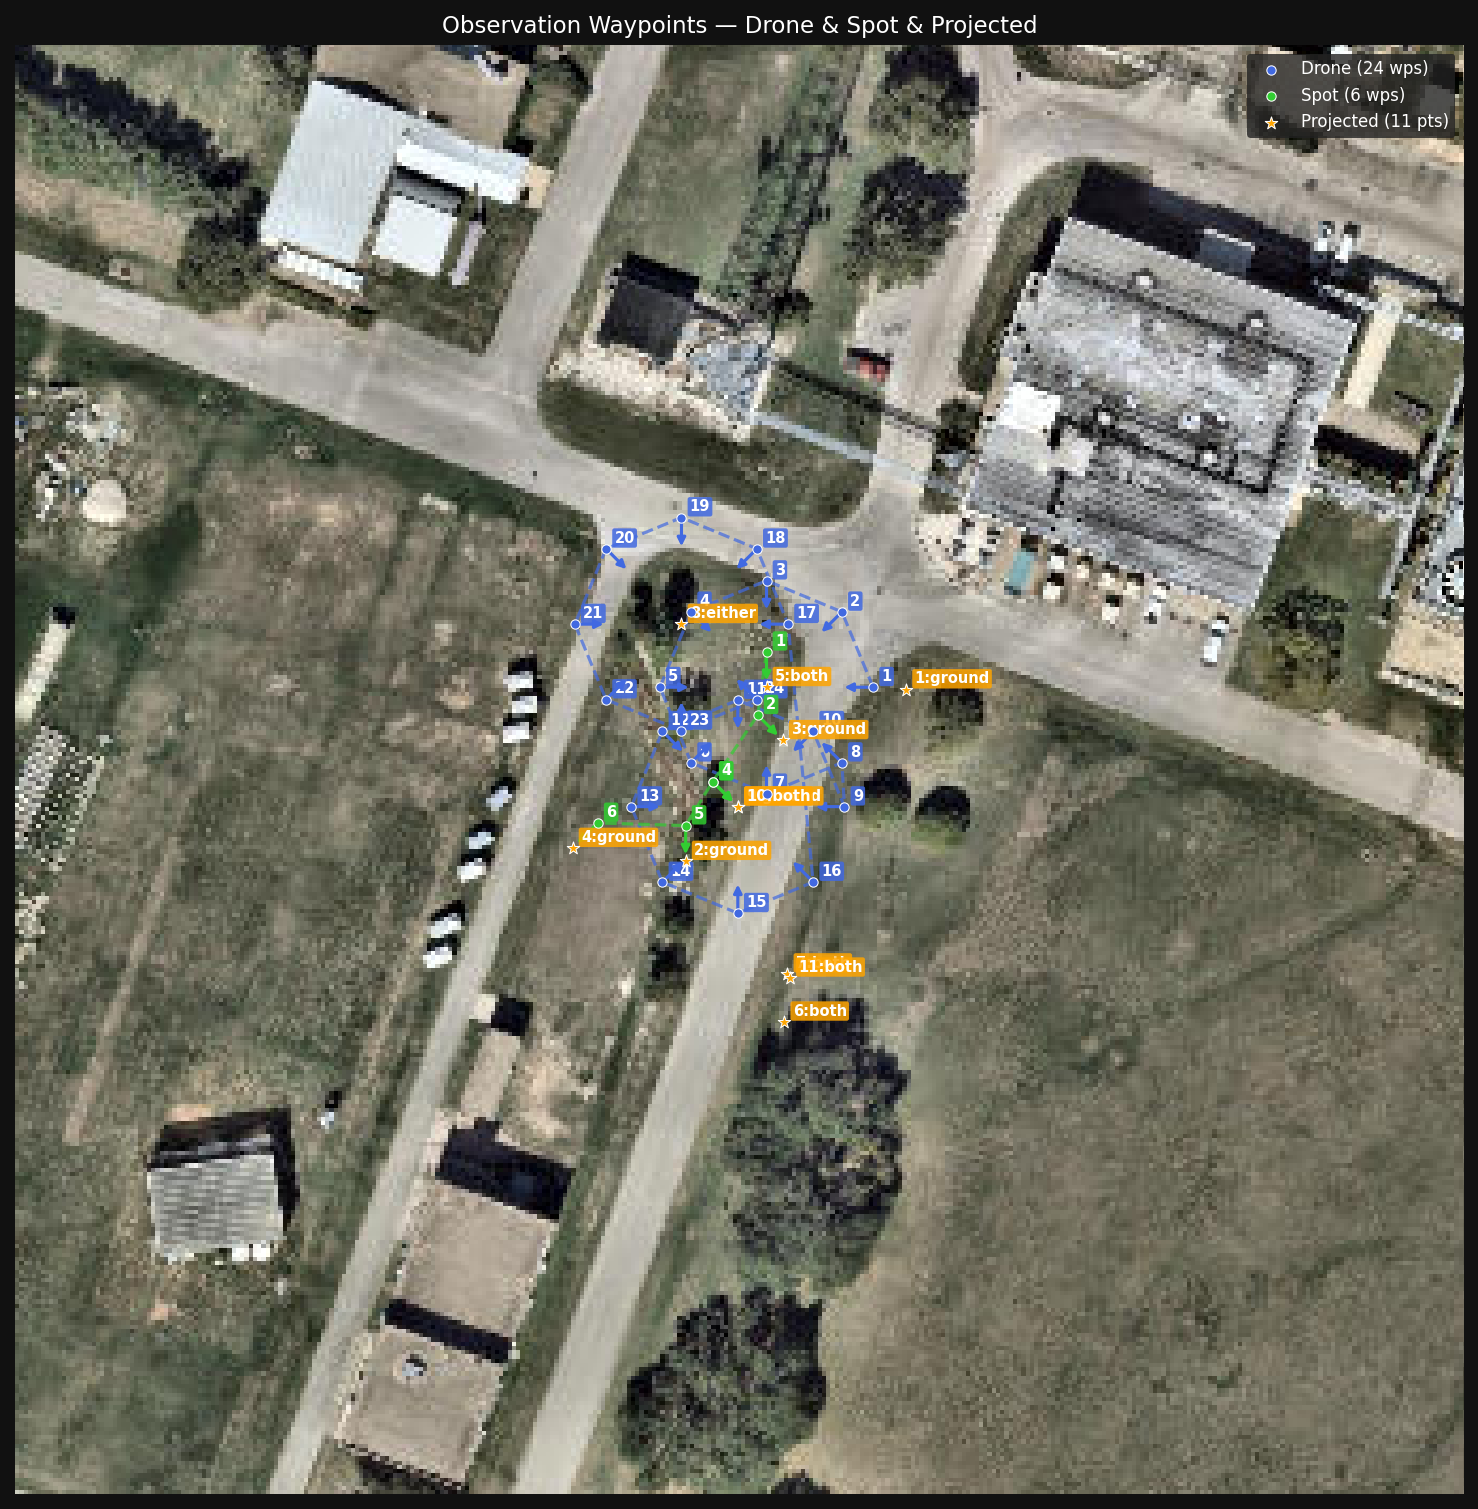

In [5]:
all_wps_latlon = [(w[0], w[1]) for w in drone_wps + spot_wps + proj_wps]
if not all_wps_latlon:
    print("No waypoints to plot.")
else:
    all_lats = [w[0] for w in all_wps_latlon]
    all_lons = [w[1] for w in all_wps_latlon]

    print(f"Fetching satellite tiles (zoom={ZOOM})...")
    img, tx_min, ty_min = fetch_basemap(all_lats, all_lons)
    print(f"Basemap: {img.shape[1]}×{img.shape[0]} px  ({img.shape[1]//TILE_SIZE}×{img.shape[0]//TILE_SIZE} tiles)")

    fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
    ax.imshow(img, origin="upper")
    ax.set_axis_off()

    def draw_vehicle(wps, color, label):
        if not wps:
            return
        pxs, pys = [], []
        for lat, lon, yaw in wps:
            px, py = _ll_to_px(lat, lon, tx_min, ty_min, ZOOM)
            pxs.append(px); pys.append(py)

        ax.plot(pxs, pys, color=color, linewidth=1.5, linestyle="--", alpha=0.7)

        for i, ((lat, lon, yaw), px, py) in enumerate(zip(wps, pxs, pys), start=1):
            ax.scatter(px, py, color=color, s=20, zorder=4,
                       edgecolors="white", linewidths=0.5)
            ax.annotate(str(i), (px, py), textcoords="offset points", xytext=(4, 3),
                        fontsize=7, fontweight="bold", color="white",
                        bbox=dict(boxstyle="round,pad=0.15", facecolor=color,
                                  edgecolor="none", alpha=0.85))
            tip_lat, tip_lon = yaw_endpoint(lat, lon, yaw, ARROW_M)
            tip_px, tip_py = _ll_to_px(tip_lat, tip_lon, tx_min, ty_min, ZOOM)
            ax.annotate("", xy=(tip_px, tip_py), xytext=(px, py),
                        arrowprops=dict(arrowstyle="-|>", color=color,
                                        lw=1.5, mutation_scale=8))

        ax.scatter([], [], color=color, s=20, edgecolors="white",
                   linewidths=0.5, label=f"{label} ({len(wps)} wps)")

    def draw_projected(wps, color, label):
        if not wps:
            return
        for i, (lat, lon, cls_label) in enumerate(wps, start=1):
            px, py = _ll_to_px(lat, lon, tx_min, ty_min, ZOOM)
            ax.scatter(px, py, color=color, s=40, zorder=5, marker="*",
                       edgecolors="white", linewidths=0.5)
            annotation = f"{i}" if cls_label is None else f"{i}:{cls_label}"
            ax.annotate(annotation, (px, py), textcoords="offset points", xytext=(4, 3),
                        fontsize=7, fontweight="bold", color="white",
                        bbox=dict(boxstyle="round,pad=0.15", facecolor=color,
                                  edgecolor="none", alpha=0.85))
        ax.scatter([], [], color=color, s=40, marker="*", edgecolors="white",
                   linewidths=0.5, label=f"{label} ({len(wps)} pts)")

    draw_vehicle(drone_wps, DRONE_COLOR, "Drone")
    draw_vehicle(spot_wps,  SPOT_COLOR,  "Spot")
    draw_projected(proj_wps, PROJ_COLOR, "Projected")

    # Zoom in 3x centered on the waypoint centroid
    all_pxs = [_ll_to_px(la, lo, tx_min, ty_min, ZOOM)[0] for la, lo in zip(all_lats, all_lons)]
    all_pys = [_ll_to_px(la, lo, tx_min, ty_min, ZOOM)[1] for la, lo in zip(all_lats, all_lons)]
    cx = (min(all_pxs) + max(all_pxs)) / 2
    cy = (min(all_pys) + max(all_pys)) / 2
    half_w = img.shape[1] / (2 * 3)
    half_h = img.shape[0] / (2 * 3)
    ax.set_xlim(cx - half_w, cx + half_w)
    ax.set_ylim(cy + half_h, cy - half_h)

    ax.legend(loc="upper right", fontsize=8,
              facecolor="#222222", edgecolor="none", labelcolor="white")
    ax.set_title("Observation Waypoints — Drone & Spot & Projected", color="white",
                 fontsize=11, pad=6)
    fig.patch.set_facecolor("#111111")
    plt.tight_layout(pad=0.5)

    PNG_OUT.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(PNG_OUT, dpi=150, bbox_inches="tight")
    print(f"Saved to {PNG_OUT}")
    plt.show()